In [1]:
# !pip install dendropy
import dendropy
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform
from dendropy.simulate import treesim
from scipy.special import logit, expit
from tqdm import tqdm
from aux_fns import *

from matplotlib import colors as mcolors
from matplotlib.patches import Patch

%load_ext autoreload
%autoreload 2

# Simulate the tree and cluster the cells

In [2]:
V, N, K = 50, 200, 4

tree = treesim.birth_death_tree(birth_rate=1.0, death_rate=0.5, num_extant_tips=N, rng=random.Random(10))

In [3]:
def assign_clones_from_tree(tree, K):
    tree.phylogenetic_distance_matrix().as_data_table().write_csv("distances.csv")
    distances_df = pd.read_csv("distances.csv", index_col=0)
    cell_ids = list(distances_df.index)

    distances = squareform(np.array(distances_df.values), checks=False)    
    linkage_matrix = linkage(distances, method="complete")
    clone_ids = fcluster(linkage_matrix, K, criterion="maxclust")
    return {cell_id:clone_id for cell_id,clone_id in zip(cell_ids,clone_ids)}, linkage_matrix

assignments, linkage_matrix = assign_clones_from_tree(tree, K)  # dict: {cell_id:clone_id, ...}
cell_ids = list(assignments.keys())
clone_ids = list(assignments.values())

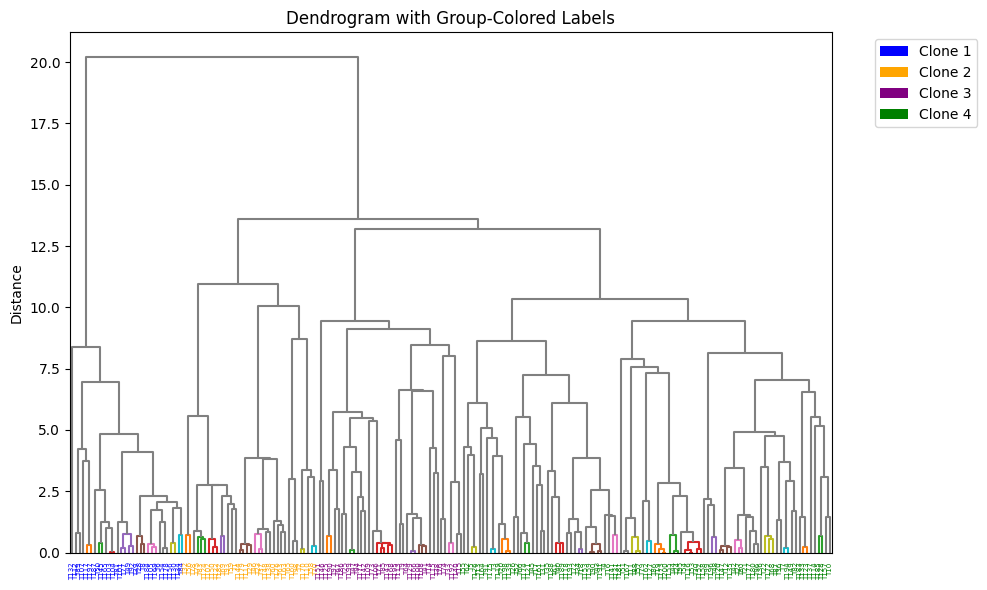

In [4]:
unique_groups = set(clone_ids)
color_list = ["blue","orange","purple","green"]
color_map = {group: color_list[i % len(color_list)] for i, group in enumerate(unique_groups)}
label_colors = [color_map[group] for group in clone_ids]

plt.figure(figsize=(10, 6))
dendro = dendrogram(linkage_matrix, labels=cell_ids, color_threshold=0.78, above_threshold_color="grey")
leaf_order = dendro["leaves"]
groupings_ordered = np.array(clone_ids)[leaf_order]

ax = plt.gca()
xlbls = ax.get_xmajorticklabels()
for lbl, group in zip(xlbls, groupings_ordered):
    lbl.set_color(color_map[group])

legend_elements = [Patch(facecolor=color_map[g], label=f'Clone {g}') for g in unique_groups]

plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.2, 1))
plt.title('Dendrogram with Group-Colored Labels')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Compute the OU kernel

In [5]:
def tree_to_edge_list(tree):
    edge_list = []
    for edge in tree.edges():
        parent = edge.tail_node  # parent node
        child = edge.head_node  # child node

        if parent is None:
            continue

        branch_length = edge.length  # branch length

        parent_label = parent.label or (parent.taxon.label if parent.taxon else None) or str(id(parent))
        child_label = child.label or (child.taxon.label if child.taxon else None) or str(id(child))
        
        edge_list.append([parent_label, child_label, branch_length])

    return edge_list

edges = tree_to_edge_list(tree)

In [6]:
kernel = compute_ou_kernel(edges, list(assignments.keys()), lambd=0.5, sigma_squared=1.0)

assert kernel.shape[0] == kernel.shape[1]
assert kernel.shape[0] == N

# Simulate mu

Here we have 4 clones with phylogeny like this

```
    M
   / \
 C1   /\
     C2 /\
       C3 C4
```

Therefore, we need to simulate
- clonal mutations (shared)
- shared mutations between C2, C3, C4
- shared mutations between C3, C4
- private mutations

In [7]:
def alpha(phi, kappa):
    return phi * kappa

def beta(phi, kappa):
    return (1-phi) * kappa

def compute_mean_frequency(k_list):
    return len([c for c in clone_ids if c in k_list]) / len(clone_ids) / 2

def get_indexes(k_list):
    return [i for i,v in enumerate(clone_ids) if v in k_list]

def sample_beta(k_list, size_rows, N):
    idxs = get_indexes(k_list)
    samples = np.zeros((size_rows, N))
    samples[:, idxs] = logit(np.random.beta(alpha(compute_mean_frequency(k_list), kappa), beta(compute_mean_frequency(k_list), kappa), size=(size_rows, len(idxs))))
    return samples

mu_true = np.zeros((V, N))
idxs = [i for i in range(V)]
clonal_mutations = np.random.choice(idxs, size=int(V * 0.3), replace=False)  # 30% of muts will be clonal
[idxs.remove(_) for _ in clonal_mutations]

shared_234 = np.random.choice(idxs, size=int(V * 0.2), replace=False)  # 20% of muts will be clonal
[idxs.remove(_) for _ in shared_234]

shared_34 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in shared_34]

private_1 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in private_1]

private_2 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in private_2]

private_3 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in private_3]

private_4 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in private_4]

kappa = 200
mu_true[clonal_mutations,:] = np.random.beta(alpha(0.5, kappa), beta(0.5, kappa), size=(len(clonal_mutations), N))

mu_true[shared_234,:] = sample_beta([2,3,4], len(shared_234), N)
mu_true[shared_34,:] = sample_beta([3,4], len(shared_34), N)

mu_true[private_1,:] = sample_beta([1], len(private_1), N)
mu_true[private_2,:] = sample_beta([2], len(private_2), N)
mu_true[private_3,:] = sample_beta([3], len(private_3), N)
mu_true[private_4,:] = sample_beta([4], len(private_4), N)

# def sample_beta(k_list, N):
#     idxs = get_indexes(k_list)
#     samples = np.zeros((N))
#     samples[idxs] = logit(np.random.beta(alpha(compute_mean_frequency(k_list), kappa), beta(compute_mean_frequency(k_list), kappa), size=(len(idxs))))
#     return samples

# mu_true = np.zeros((K, N))

# mu_true[0,:] = sample_beta([1], N)
# mu_true[1,:] = sample_beta([2], N)
# mu_true[2,:] = sample_beta([3], N)
# mu_true[3,:] = sample_beta([4], N)

# Simulate gamma and sample observed variables

In [8]:
gamma_true = np.zeros((V, N))
for v in range(V):
    for k in range(K):
        # idxs = get_indexes([k])
        gamma_true[v,:] = np.random.multivariate_normal(mu_true[k,:], kernel / 20)

theta_true = expit(gamma_true)
DP_true = np.full((V,N), 100) + np.round(np.random.normal(0, 1, size=(V,N))).astype(int)
AD_true = np.random.binomial(DP_true, theta_true)

In [9]:
def array_to_df(array, value_name):
    df = pd.DataFrame(array)
    df.columns = cell_ids
    df["mutation_ids"] = df.index
    df = pd.melt(df, id_vars=["mutation_ids"], value_vars=cell_ids, var_name="cell_ids", value_name=value_name)
    return df

In [10]:
data_true = pd.concat([array_to_df(theta_true, "VAF"), \
                       array_to_df(AD_true, "AD")["AD"], \
                       array_to_df(DP_true, "DP")["DP"], \
                       array_to_df(gamma_true, "gamma")["gamma"]], \
                       axis=1, join="inner")
data_true["clone_ids"] = [str(assignments[i]) for i in data_true["cell_ids"]]
data_true.head()

,mutation_ids,cell_ids,VAF,AD,DP,gamma,clone_ids
0,0,T101,0.532650,50,101,0.130784,1
1,1,T101,0.635585,64,100,0.556251,1
2,2,T101,0.642675,58,100,0.586993,1
3,3,T101,0.662680,72,100,0.675262,1
4,4,T101,0.572844,57,100,0.293462,1


array([[<Axes: title={'center': '1'}>, <Axes: title={'center': '2'}>],
       [<Axes: title={'center': '3'}>, <Axes: title={'center': '4'}>]],
      dtype=object)

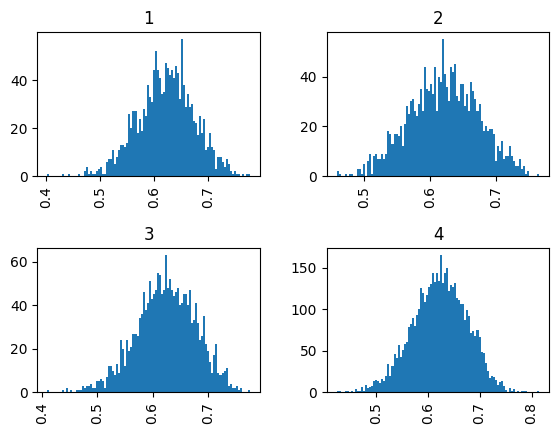

In [11]:
data_true[["VAF", "clone_ids"]].hist(by="clone_ids", bins=100)

/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


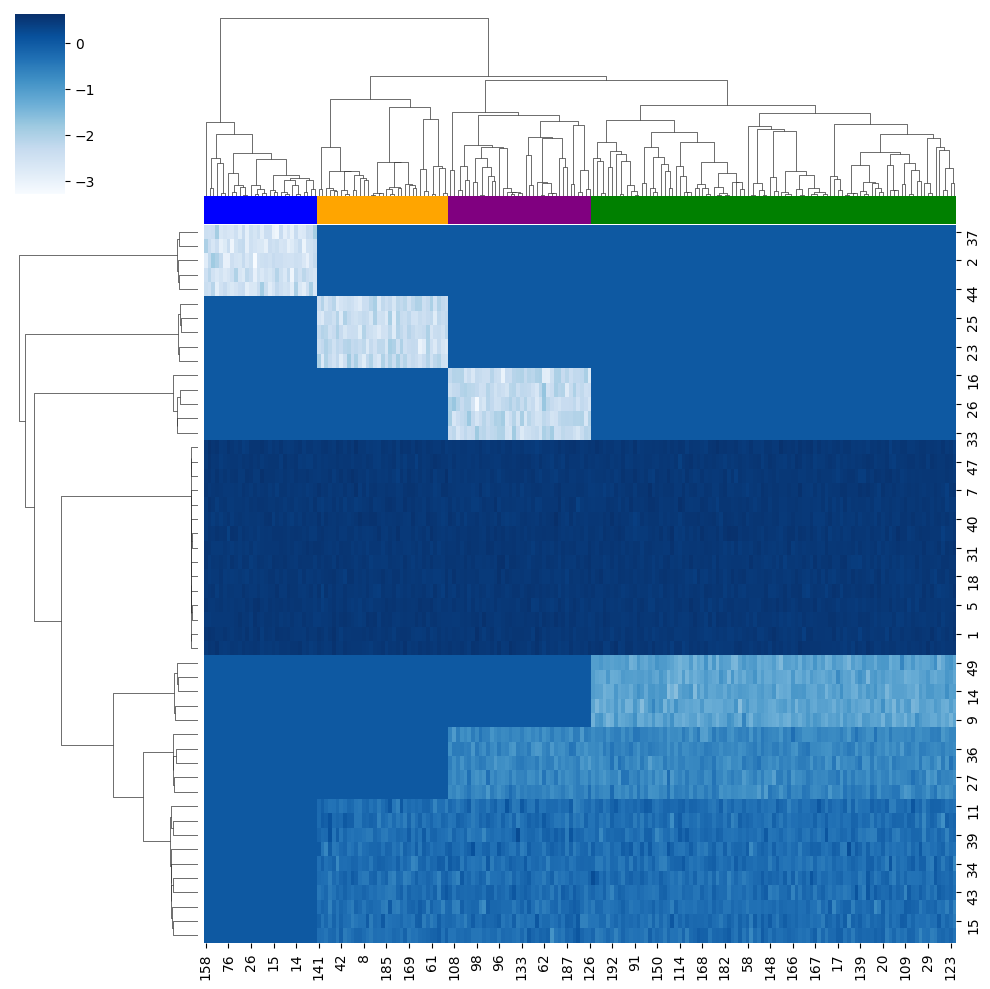

In [12]:
sns.clustermap(mu_true, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues")

# Run the model

In [13]:
import torch
import time
import torch.nn as nn
import torch.optim as optim
import numpy as np

from torch.autograd.functional import hessian
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# device = torch.device("cuda")
device = torch.device("mps")

In [15]:
# convert to tensor the data
Y = torch.tensor(AD_true).to(device=device)
D = torch.tensor(DP_true).to(device=device)
Z = torch.tensor(clone_ids, dtype=torch.int, device=device)

V, N = Y.shape  # #mutations x #cells
K = len(Z.unique())  # #clones

assert Y.shape[1] == D.shape[1]
assert Y.shape[1] == Z.shape[0]
print(f"{V} SNPs, {N} cells and {K} clones\n")

print(f"Devices\nY = {Y.device}\nD = {D.device}\nZ = {Z.device}")

50 SNPs, 200 cells and 4 clones

Devices
Y = mps:0
D = mps:0
Z = mps:0


In [ ]:
# mu = [torch.zeros(N, requires_grad=True, dtype=torch.float32, device=device) for _ in range(K)]
mu = torch.full((V,N), fill_value=0.5, requires_grad=True, dtype=torch.float32, device=device)

Sigma = torch.tensor(kernel, dtype=torch.float32, device=device) + 1e-6*torch.eye(N, device=device)
Sigma_inv = torch.linalg.inv(Sigma)  # inverese of Sigma -> N x N
log_det_Sigma = torch.logdet(Sigma)  # log of determinant of Sigma

print(f"Devices\nmu = {mu.device}\nSigma = {Sigma.device}\nSigma_inv = {Sigma_inv.device}\nlog_det_Sigma = {log_det_Sigma.device}")

start_time = time.time()

optimizer = optim.Adam([mu], lr=0.005)
losses = []
# for epoch in range(100):
for i in tqdm(range(100)):
    optimizer.zero_grad()  # reset the gradient

    # gamma_store = torch.zeros((V, K, N))  # store all gammas
    gamma_store = torch.zeros((V, N))  # store all gammas
    total_laplace = 0.0
    for v in range(V):
        for k in np.unique(Z.to("cpu")):
            # compute log p(y_v | d_v, mu_v, Sigma) with laplace approx
            y_v = Y[v, :]
            d_v = D[v, :]
            # laplace_term, gamma_hat = compute_laplace_term(y_v, d_v, mu[k-1], Sigma_inv, Z, k)
            laplace_term, gamma_hat = compute_laplace_term(y_v, d_v, mu[v,:], Sigma_inv, Z, k)
            total_laplace += laplace_term
            gamma_store[v, k-1] = gamma_hat

    loss = -total_laplace
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    # print(f"Epoch {epoch}: Loss = {loss.item():.3f}")

end_time = time.time()

Devices
mu = mps:0
Sigma = mps:0
Sigma_inv = mps:0
log_det_Sigma = mps:0


100%|██████████| 100/100 [05:17<00:00,  3.18s/it]


# Evaluation

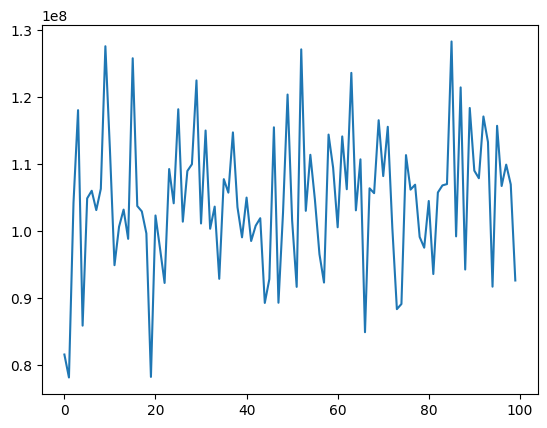

In [21]:
plt.plot(losses)

In [18]:
mu_np = mu.cpu().detach().numpy()
# mu_np = np.nan_to_num(mu_np, nan=0.0)

/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


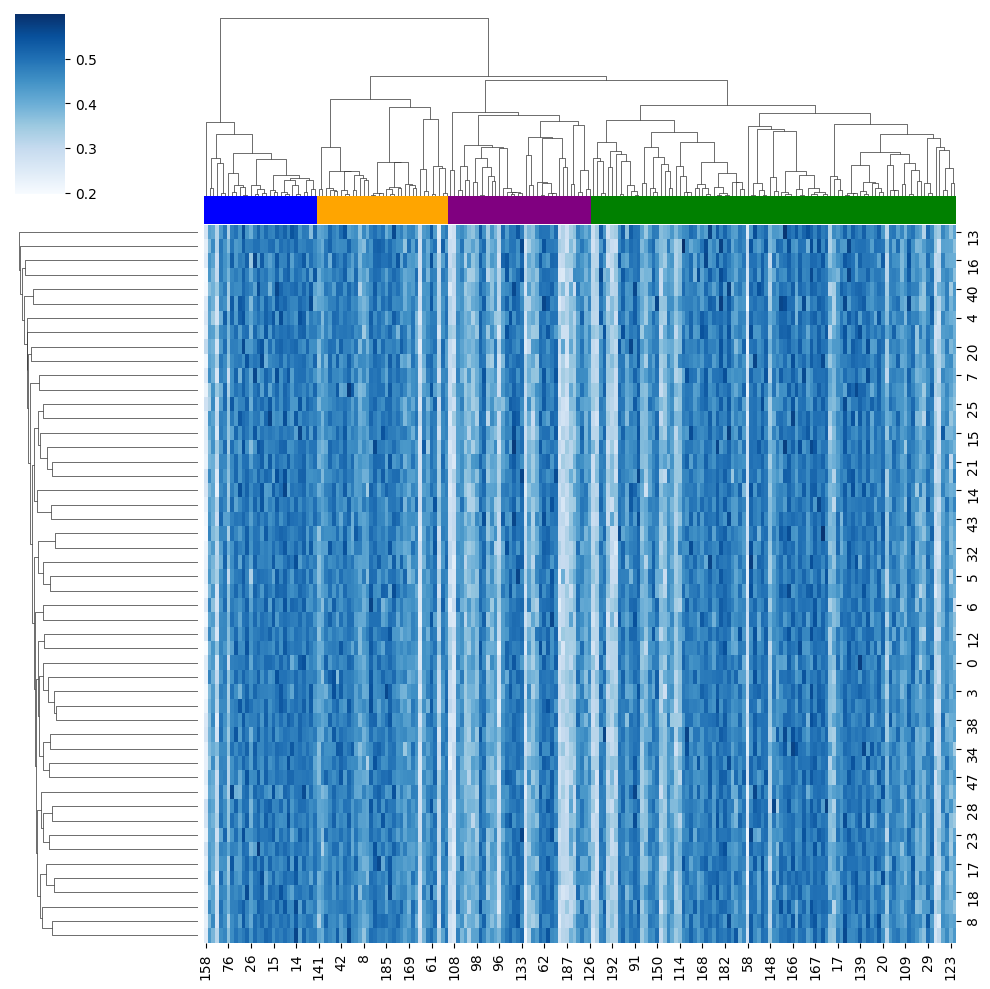

In [19]:
sns.clustermap(mu_np, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues")

/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


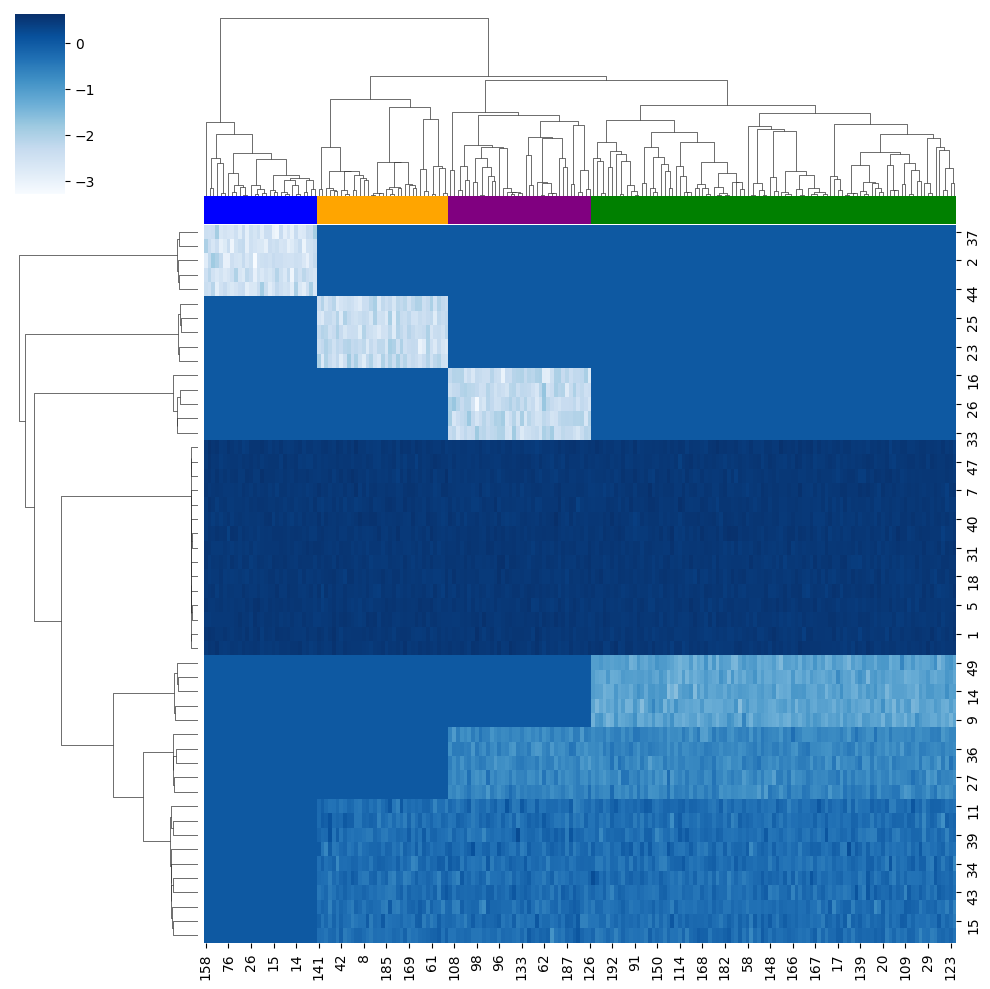

In [20]:
sns.clustermap(mu_true, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues")

In [ ]:
gamma_store.shape

torch.Size([50, 4, 200])

/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


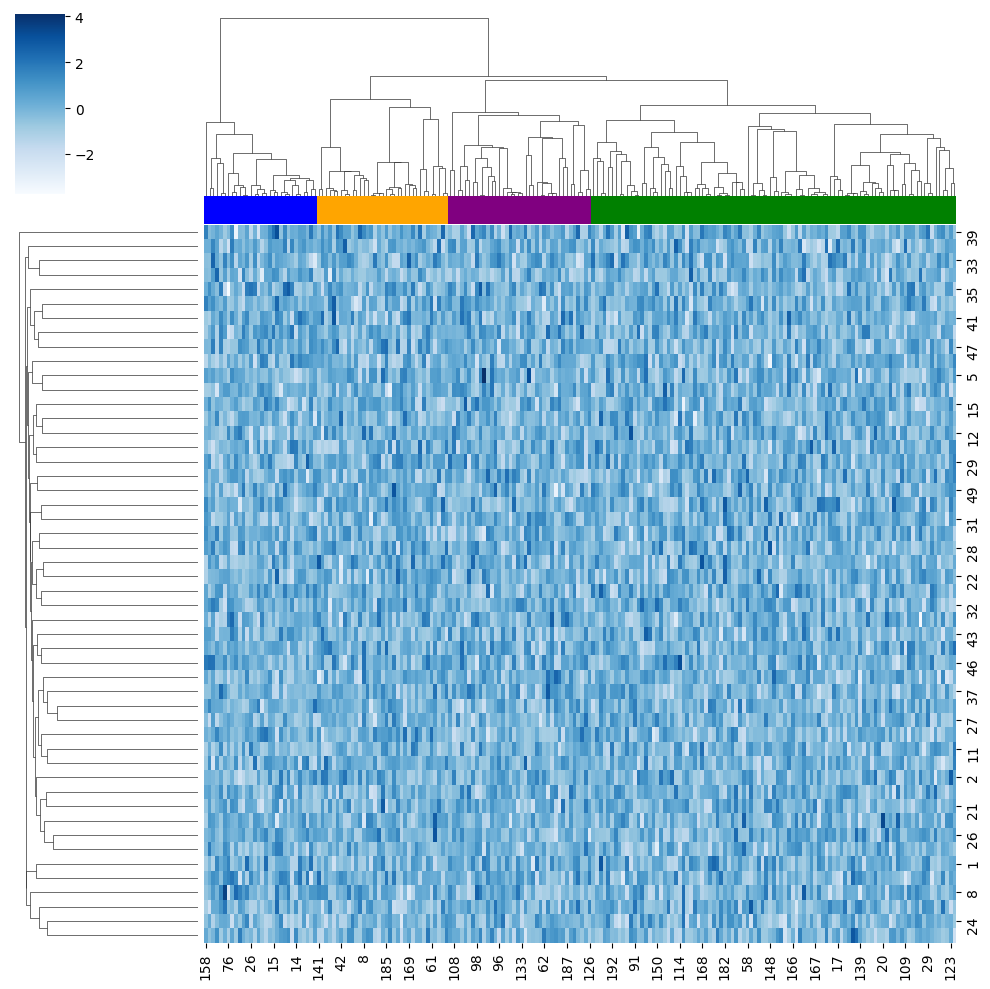

In [29]:
sns.clustermap(gamma_store[:,3,:], col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues")